In [108]:
#train pipleline


In [201]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import gaussian_filter

In [202]:
N_BINS = 80

SIGMA = 1.0

EPS = 1e-10

SKIP_TIMESTEPS = 50

GAUSSIAN_KERNEL = (5, 5)


In [203]:
def get_input_data(
    pkl_path,
    layer_name,
):
    """
    Load the 2D trajectory dataset.

    Returns
    -------
    ground_truth : (n_traj, T, 2)

    prediction : (n_traj, T, 2)

    positions : (n_traj, T, 2)

    activations : (n_traj, T, n_neurons)
    """

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    ground_truth = np.asarray(data["ground_truth"])

    prediction = np.asarray(data["prediction"])

    activations = np.asarray(data[layer_name])

    positions = prediction.copy()

    if SKIP_TIMESTEPS > 0:

        ground_truth = ground_truth[:, SKIP_TIMESTEPS:, :]

        prediction = prediction[:, SKIP_TIMESTEPS:, :]

        positions = positions[:, SKIP_TIMESTEPS:, :]

        activations = activations[:, SKIP_TIMESTEPS:, :]

    return (
        ground_truth,
        prediction,
        positions,
        activations,
    )

In [204]:
def get_arena_bounds(positions):
    """
    Compute global arena bounds across all trajectories.

    Parameters
    ----------
    positions : ndarray
        Shape (n_traj, T, 2)

    Returns
    -------
    bounds : tuple
        (xmin, xmax, ymin, ymax)
    """

    xmin = np.min(positions[:, :, 0])
    xmax = np.max(positions[:, :, 0])

    ymin = np.min(positions[:, :, 1])
    ymax = np.max(positions[:, :, 1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [205]:
def get_arena_bounds(positions_list):
    """
    Compute global arena bounds shared across every trajectory.
    """

    all_positions = np.concatenate(positions_list, axis=0)

    xmin = np.min(all_positions[:,0])
    xmax = np.max(all_positions[:,0])

    ymin = np.min(all_positions[:,1])
    ymax = np.max(all_positions[:,1])

    return (
        float(xmin),
        float(xmax),
        float(ymin),
        float(ymax),
    )

In [206]:
def bin_positions(
    positions,
    bins=N_BINS,
    bounds=None,
):
    """
    Assign every (x, y) position sample to a spatial bin.

    Parameters
    ----------
    positions : ndarray
        Shape (T, 2)

    bins : int
        Number of bins along each dimension.

    bounds : tuple
        (xmin, xmax, ymin, ymax)

    Returns
    -------
    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    x_edges : ndarray
        Bin edges along x.

    y_edges : ndarray
        Bin edges along y.
    """

    xmin, xmax, ymin, ymax = bounds

    x_edges = np.linspace(xmin, xmax, bins + 1)
    y_edges = np.linspace(ymin, ymax, bins + 1)

    x_bin = np.digitize(
        positions[:, 0],
        x_edges,
    ) - 1

    y_bin = np.digitize(
        positions[:, 1],
        y_edges,
    ) - 1

    # Keep indices inside the grid
    x_bin = np.clip(x_bin, 0, bins - 1)
    y_bin = np.clip(y_bin, 0, bins - 1)

    return x_bin, y_bin, x_edges, y_edges

In [207]:
def compute_occupancy_maps(
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D occupancy maps.

    Parameters
    ----------
    x_bin : ndarray
    y_bin : ndarray

    Returns
    -------
    count_occupancy : (bins,bins)

    probability_occupancy : (bins,bins)
    """

    count_occupancy = np.zeros((bins, bins), dtype=float)

    # Count visits
    for xb, yb in zip(x_bin, y_bin):
        count_occupancy[yb, xb] += 1

    total = np.sum(count_occupancy)

    if total > 0:
        probability_occupancy = count_occupancy / total
    else:
        probability_occupancy = np.zeros_like(count_occupancy)

    return count_occupancy, probability_occupancy

In [208]:
def compute_activity_maps(
    activity,
    x_bin,
    y_bin,
    bins=N_BINS,
):
    """
    Compute 2D activity maps for ONE neuron.

    Parameters
    ----------
    activity : ndarray
        Shape (T,)

    x_bin : ndarray
        Shape (T,)

    y_bin : ndarray
        Shape (T,)

    Returns
    -------
    amplitude_activity : (bins, bins)

    real_activity : (bins, bins)
    """

    amplitude = np.abs(activity)

    real = np.real(activity)

    amplitude_activity = np.zeros((bins, bins), dtype=float)

    real_activity = np.zeros((bins, bins), dtype=float)

    for a, r, xb, yb in zip(
        amplitude,
        real,
        x_bin,
        y_bin,
    ):

        amplitude_activity[yb, xb] += a

        real_activity[yb, xb] += r

    return amplitude_activity, real_activity

In [209]:
def compute_firing_rate_map(
    activity_map,
    occupancy_map,
    eps=EPS,
):
    """
    Compute firing-rate map.

    Works for both 1D and 2D arrays.

    Parameters
    ----------
    activity_map : ndarray
    occupancy_map : ndarray

    Returns
    -------
    firing_rate_map : ndarray
    """

    firing_rate = np.divide(
        activity_map,
        occupancy_map + eps,
    )

    firing_rate[occupancy_map == 0] = 0

    return firing_rate

In [210]:
from scipy.signal import convolve2d


def matlab_style_gauss2D(shape=(5, 5), sigma=1.0):
    """
    2D Gaussian mask equivalent to MATLAB's

        fspecial('gaussian', shape, sigma)

    Parameters
    ----------
    shape : tuple
        Size of the Gaussian kernel.

    sigma : float
        Standard deviation of the Gaussian.

    Returns
    -------
    h : ndarray
        Normalized Gaussian kernel.
    """

    m, n = [(ss - 1.) / 2. for ss in shape]

    y, x = np.ogrid[-m:m+1, -n:n+1]

    h = np.exp(-(x*x + y*y) / (2.0 * sigma * sigma))

    h[h < np.finfo(h.dtype).eps * h.max()] = 0

    if h.sum() != 0:
        h /= h.sum()

    return h


def smooth_firing_rate_map(
    firing_rate_map,
    sigma=SIGMA,
    kernel_shape=GAUSSIAN_KERNEL,
):
    """
    Smooth a firing-rate map using a MATLAB-style Gaussian kernel.

    Parameters
    ----------
    firing_rate_map : ndarray
        2D firing-rate map.

    sigma : float
        Gaussian standard deviation.

    kernel_shape : tuple
        Kernel size used by MATLAB's fspecial.
    """

    kernel = matlab_style_gauss2D(
        shape=kernel_shape,
        sigma=sigma,
    )

    smoothed = convolve2d(
        firing_rate_map,
        kernel,
        mode="same",
        boundary="symm",
    )

    return smoothed

In [211]:
def spatial_information(rate_map, occupancy_map):
    """
    Spatial Information (bits/spike)

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map

    occupancy_map : ndarray
        Count or probability occupancy
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
        & (rate_map > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    r_bar = np.sum(p * r)

    if r_bar <= EPS:
        return np.nan

    ratio = r / r_bar

    return np.sum(
        p * ratio * np.log2(ratio)
    )

In [212]:
def sparsity(rate_map, occupancy_map):
    """
    Population sparsity
    """

    occ = occupancy_map.astype(float)
    occ = occ / occ.sum()

    valid = (
        (~np.isnan(rate_map))
        & (occ > 0)
    )

    if np.sum(valid) == 0:
        return np.nan

    p = occ[valid]
    r = rate_map[valid]

    mean_r = np.sum(p * r)
    mean_r2 = np.sum(p * r**2)

    if mean_r2 <= EPS:
        return np.nan

    return (mean_r**2) / mean_r2

In [213]:
def evaluate_place_cell(rate_map, occupancy_map):
    """
    Compute place-cell metrics from a raw firing-rate map.
    """

    return {
        "Spatial Information": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

#main


In [214]:
import pickle
import numpy as np

layer_name = "d4"

trajectory_results_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"

ground_truth, prediction, positions, activations = get_input_data(
    trajectory_results_path,
    layer_name,
)

In [215]:
print("Ground Truth :", ground_truth.shape)
print("Prediction   :", prediction.shape)
print("Positions    :", positions.shape)
print("Activations  :", activations.shape)

Ground Truth : (500, 450, 2)
Prediction   : (500, 450, 2)
Positions    : (500, 450, 2)
Activations  : (500, 450, 100)


In [216]:
bounds = get_arena_bounds(positions)

print(bounds)

(0.027809273451566696, 0.9689222574234009, 0.0295569971203804, 0.9583374857902527)


In [217]:
trajectory = 0
neuron = 0

trajectory_positions = positions[trajectory]

activity = activations[trajectory, :, neuron]

print("Trajectory positions:", trajectory_positions.shape)
print("Neuron activity:", activity.shape)

Trajectory positions: (450, 2)
Neuron activity: (450,)


In [218]:
x_bin, y_bin, x_edges, y_edges = bin_positions(
    trajectory_positions,
    bins=N_BINS,
    bounds=bounds,
)

print("x bins:", x_bin.shape)
print("y bins:", y_bin.shape)

print()

print("x range:", x_bin.min(), "to", x_bin.max())
print("y range:", y_bin.min(), "to", y_bin.max())

print()

print("First 10 x bins:", x_bin[:10])
print("First 10 y bins:", y_bin[:10])

x bins: (450,)
y bins: (450,)

x range: 17 to 73
y range: 4 to 72

First 10 x bins: [46 47 47 47 48 48 49 50 51 51]
First 10 y bins: [12 12 12 12 12 12 12 12 12 13]


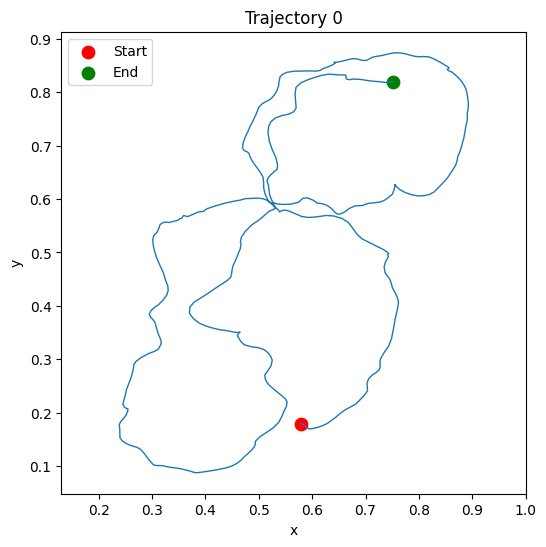

In [219]:
plt.figure(figsize=(6,6))

plt.plot(
    trajectory_positions[:,0],
    trajectory_positions[:,1],
    lw=1,
)

plt.scatter(
    trajectory_positions[0,0],
    trajectory_positions[0,1],
    c="red",
    s=80,
    label="Start",
)

plt.scatter(
    trajectory_positions[-1,0],
    trajectory_positions[-1,1],
    c="green",
    s=80,
    label="End",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory 0")

plt.legend()
plt.axis("equal")

plt.show()

In [220]:
count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

print("Count occupancy shape:", count_occ.shape)
print("Probability occupancy shape:", prob_occ.shape)

print()

print("Total samples:", count_occ.sum())
print("Probability sum:", prob_occ.sum())

Count occupancy shape: (80, 80)
Probability occupancy shape: (80, 80)

Total samples: 450.0
Probability sum: 0.9999999999999999


In [221]:
amp_activity, real_activity = compute_activity_maps(
    activity,
    x_bin,
    y_bin,
)

In [222]:
print("Amplitude Activity Shape:", amp_activity.shape)
print("Real Activity Shape:", real_activity.shape)

print()

print("Total Amplitude:", amp_activity.sum())
print("Total Real:", real_activity.sum())


Amplitude Activity Shape: (80, 80)
Real Activity Shape: (80, 80)

Total Amplitude: 111.7937190250168
Total Real: 109.16579863274


In [223]:
amp_count_rate = compute_firing_rate_map(
    amp_activity,
    count_occ,
)

amp_prob_rate = compute_firing_rate_map(
    amp_activity,
    prob_occ,
)

real_count_rate = compute_firing_rate_map(
    real_activity,
    count_occ,
)

real_prob_rate = compute_firing_rate_map(
    real_activity,
    prob_occ,
)

In [225]:
print("Amplitude / Count:", amp_count_rate.shape)
print("Amplitude / Probability:", amp_prob_rate.shape)

print("Real / Count:", real_count_rate.shape)
print("Real / Probability:", real_prob_rate.shape)

Amplitude / Count: (80, 80)
Amplitude / Probability: (80, 80)
Real / Count: (80, 80)
Real / Probability: (80, 80)


In [226]:
maps = {
    "Amplitude / Count": (
        amp_count_rate,
        count_occ,
    ),

    "Amplitude / Probability": (
        amp_prob_rate,
        prob_occ,
    ),

    "Real / Count": (
        real_count_rate,
        count_occ,
    ),

    "Real / Probability": (
        real_prob_rate,
        prob_occ,
    ),
}

results = {}

for name, (rate_map, occupancy) in maps.items():

    results[name] = evaluate_place_cell(
        rate_map,
        occupancy,
    )

In [227]:
print("\n" + "="*70)
print("PLACE CELL METRICS")
print("="*70)

print(f"{'Method':30s} {'SI':>12s} {'Sparsity':>12s}")

print("-"*70)

for name, metrics in results.items():

    print(
        f"{name:30s}"
        f"{metrics['Spatial Information']:12.5f}"
        f"{metrics['Sparsity']:12.5f}"
    )


PLACE CELL METRICS
Method                                   SI     Sparsity
----------------------------------------------------------------------
Amplitude / Count                  1.41437     0.30359
Amplitude / Probability            1.41437     0.30359
Real / Count                       1.51097     0.28952
Real / Probability                 1.51097     0.28952


In [228]:
amp_count_smoothed = smooth_firing_rate_map(amp_count_rate)

amp_prob_smoothed = smooth_firing_rate_map(amp_prob_rate)

real_count_smoothed = smooth_firing_rate_map(real_count_rate)

real_prob_smoothed = smooth_firing_rate_map(real_prob_rate)

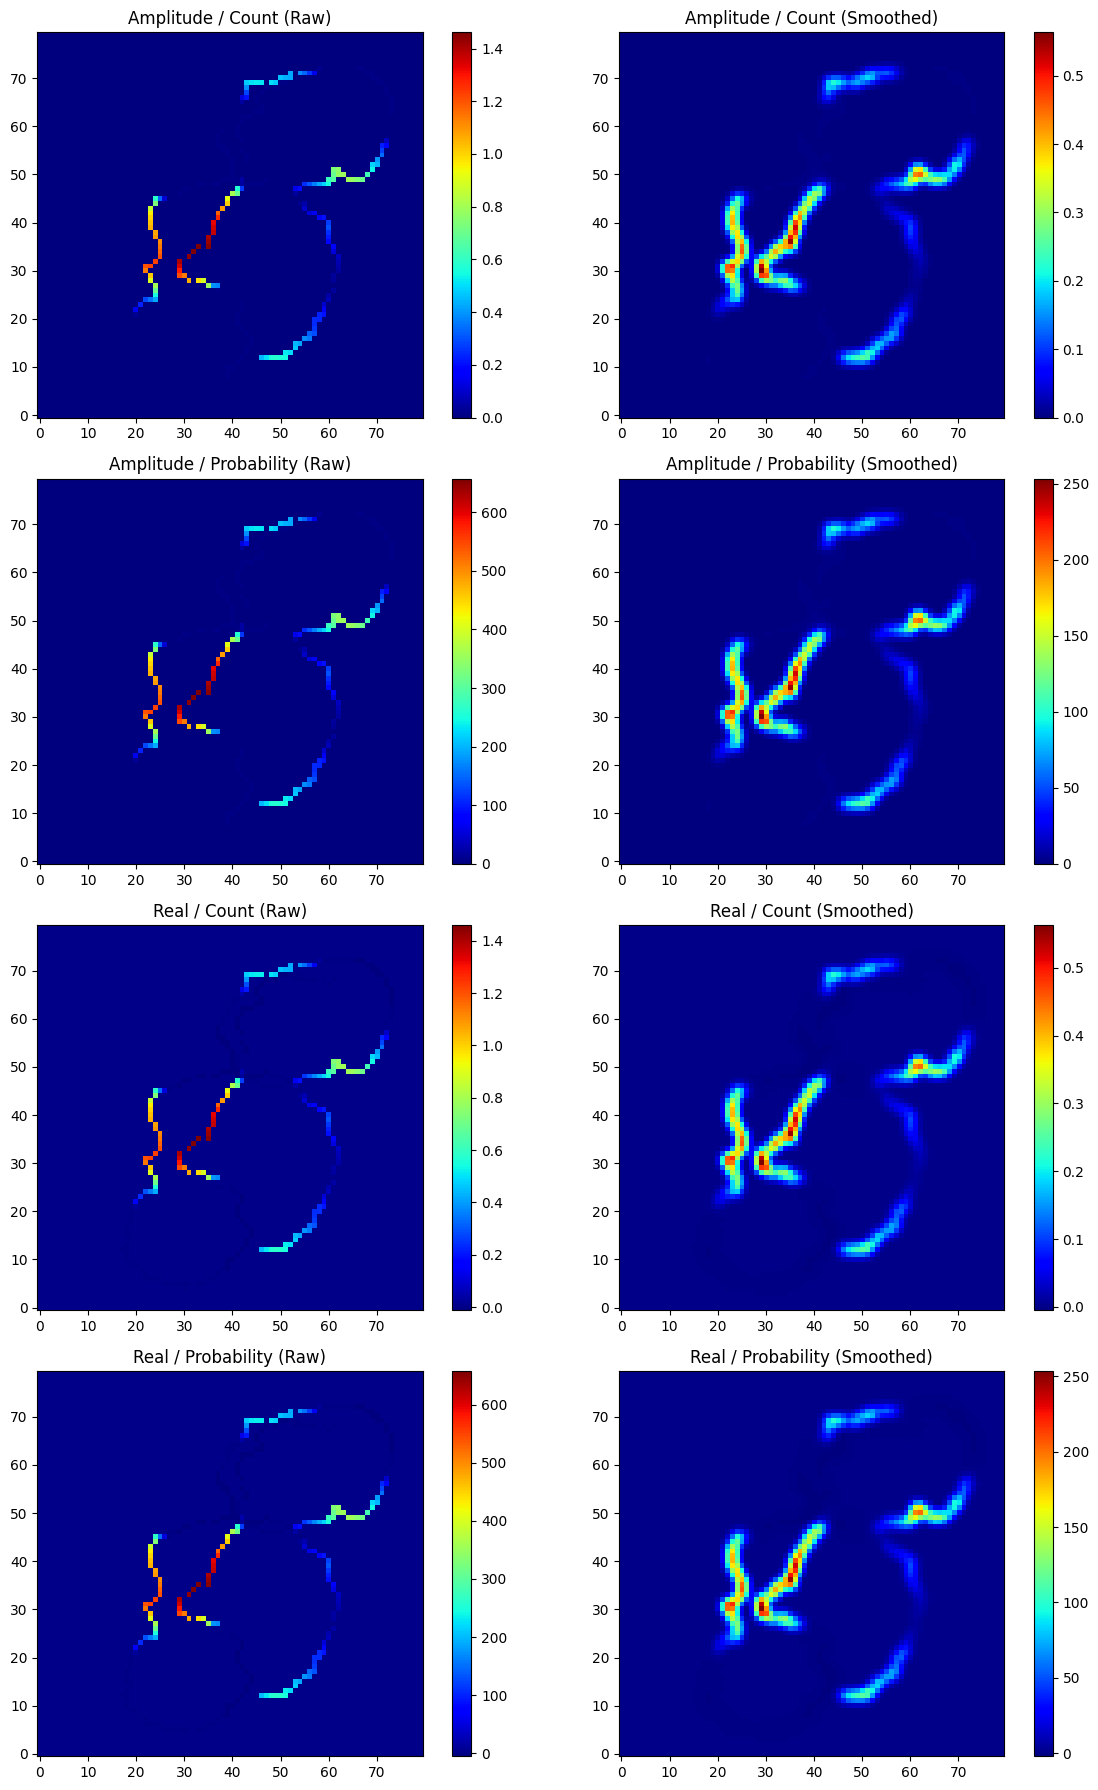

In [230]:
fig, ax = plt.subplots(4, 2, figsize=(12, 18))

maps = [

    ("Amplitude / Count",
     amp_count_rate,
     amp_count_smoothed),

    ("Amplitude / Probability",
     amp_prob_rate,
     amp_prob_smoothed),

    ("Real / Count",
     real_count_rate,
     real_count_smoothed),

    ("Real / Probability",
     real_prob_rate,
     real_prob_smoothed),
]

for row, (title, raw, smooth) in enumerate(maps):

    im = ax[row, 0].imshow(
        raw,
        origin="lower",
        interpolation="nearest",
        cmap="jet"
    )

    ax[row, 0].set_title(f"{title} (Raw)")
    plt.colorbar(im, ax=ax[row, 0])

    im = ax[row, 1].imshow(
        smooth,
        origin="lower",
        interpolation="nearest",
        cmap="jet"
    )

    ax[row, 1].set_title(f"{title} (Smoothed)")
    plt.colorbar(im, ax=ax[row, 1])

plt.tight_layout()

plt.show()

In [231]:
all_results = []

trajectory = 0

trajectory_positions = positions[trajectory]

x_bin, y_bin, _, _ = bin_positions(
    trajectory_positions,
    bins=N_BINS,
    bounds=bounds,
)

count_occ, prob_occ = compute_occupancy_maps(
    x_bin,
    y_bin,
)

n_neurons = activations.shape[2]

for neuron in range(n_neurons):

    activity = activations[
        trajectory,
        :,
        neuron,
    ]

    amp_activity, real_activity = compute_activity_maps(
        activity,
        x_bin,
        y_bin,
    )

    amp_count = compute_firing_rate_map(
        amp_activity,
        count_occ,
    )

    amp_prob = compute_firing_rate_map(
        amp_activity,
        prob_occ,
    )

    real_count = compute_firing_rate_map(
        real_activity,
        count_occ,
    )

    real_prob = compute_firing_rate_map(
        real_activity,
        prob_occ,
    )

    amp_count_s = smooth_firing_rate_map(
        amp_count,
    )

    amp_prob_s = smooth_firing_rate_map(
        amp_prob,
    )

    real_count_s = smooth_firing_rate_map(
        real_count,
    )

    real_prob_s = smooth_firing_rate_map(
        real_prob,
    )

    all_results.append({

        "neuron": neuron,

        "amp_count_smoothed": amp_count_s,
        "amp_prob_smoothed": amp_prob_s,

        "real_count_smoothed": real_count_s,
        "real_prob_smoothed": real_prob_s,

    })

print(f"Processed {len(all_results)} neurons.")

Processed 100 neurons.


In [232]:
def evaluate_place_cell(
    rate_map,
    occupancy_map,
):
    """
    Compute place-cell metrics for one firing-rate map.

    Parameters
    ----------
    rate_map : ndarray
        Smoothed firing-rate map.

    occupancy_map : ndarray
        Count or probability occupancy map.

    Returns
    -------
    metrics : dict
        Spatial Information and Sparsity.
    """

    return {
        "SI": spatial_information(
            rate_map,
            occupancy_map,
        ),
        "Sparsity": sparsity(
            rate_map,
            occupancy_map,
        ),
    }

In [233]:
maps = {
    "Amplitude / Count": (
        amp_count_smoothed,
        count_occ,
    ),

    "Amplitude / Probability": (
        amp_prob_smoothed,
        prob_occ,
    ),

    "Real / Count": (
        real_count_smoothed,
        count_occ,
    ),

    "Real / Probability": (
        real_prob_smoothed,
        prob_occ,
    ),
}

results = {}

for name, (rate_map, occ) in maps.items():

    results[name] = evaluate_place_cell(
        rate_map,
        occ,
    )

In [234]:
results = {}

maps = {
    "Amplitude / Count": (amp_count_smoothed, count_occ),
    "Amplitude / Probability": (amp_prob_smoothed, prob_occ),
    "Real / Count": (real_count_smoothed, count_occ),
    "Real / Probability": (real_prob_smoothed, prob_occ),
}

for name, (rate_map, occupancy) in maps.items():

    si = spatial_information(
        rate_map,
        occupancy,
    )

    sp = sparsity(
        rate_map,
        occupancy,
    )

    results[name] = {
        "Spatial Information": si,
        "Sparsity": sp,
    }

In [242]:
import pandas as pd

results_df = []

for result in all_results:

    neuron = result["neuron"]

    rate_map = result["amp_count_smoothed"]

    si = spatial_information(
        rate_map,
        count_occ,
    )

    sp = sparsity(
        rate_map,
        count_occ,
    )

    results_df.append({

        "Neuron": neuron,

        "SI": si,

        "Sparsity": sp,

    })

results_df = pd.DataFrame(results_df)
results_df["Neuron"] = results_df["Neuron"].astype(int)

results_df.head()

,Neuron,SI,Sparsity
0,0,1.219690,0.346509
1,1,1.287697,0.341174
2,2,0.538851,0.616689
3,3,0.918469,0.455344
4,4,1.331360,0.324346


In [243]:
SI_THRESHOLD = 0.5
SPARSITY_THRESHOLD = 0.3

place_cells = results_df[
    (results_df["SI"] >= SI_THRESHOLD) &
    (results_df["Sparsity"] <= SPARSITY_THRESHOLD)
]

print(place_cells)

    Neuron        SI  Sparsity
8        8  1.408060  0.297803
10      10  1.964384  0.201955
14      14  1.634728  0.234900
23      23  1.769494  0.221257
25      25  1.718177  0.229838
26      26  1.473951  0.283450
32      32  1.558665  0.250769
37      37  2.037843  0.170149
39      39  1.619618  0.225433
44      44  2.009443  0.182758
53      53  1.733510  0.193555
54      54  1.373479  0.289568
56      56  1.471671  0.268321
62      62  1.494803  0.262592
64      64  1.708407  0.228927
67      67  1.587952  0.277310
69      69  1.694238  0.220068
71      71  2.000443  0.182823
76      76  2.167144  0.143594
77      77  1.999008  0.178027
78      78  2.096988  0.153835
79      79  2.194616  0.143236
87      87  1.537103  0.280643
94      94  1.823287  0.198593
96      96  1.475185  0.271548


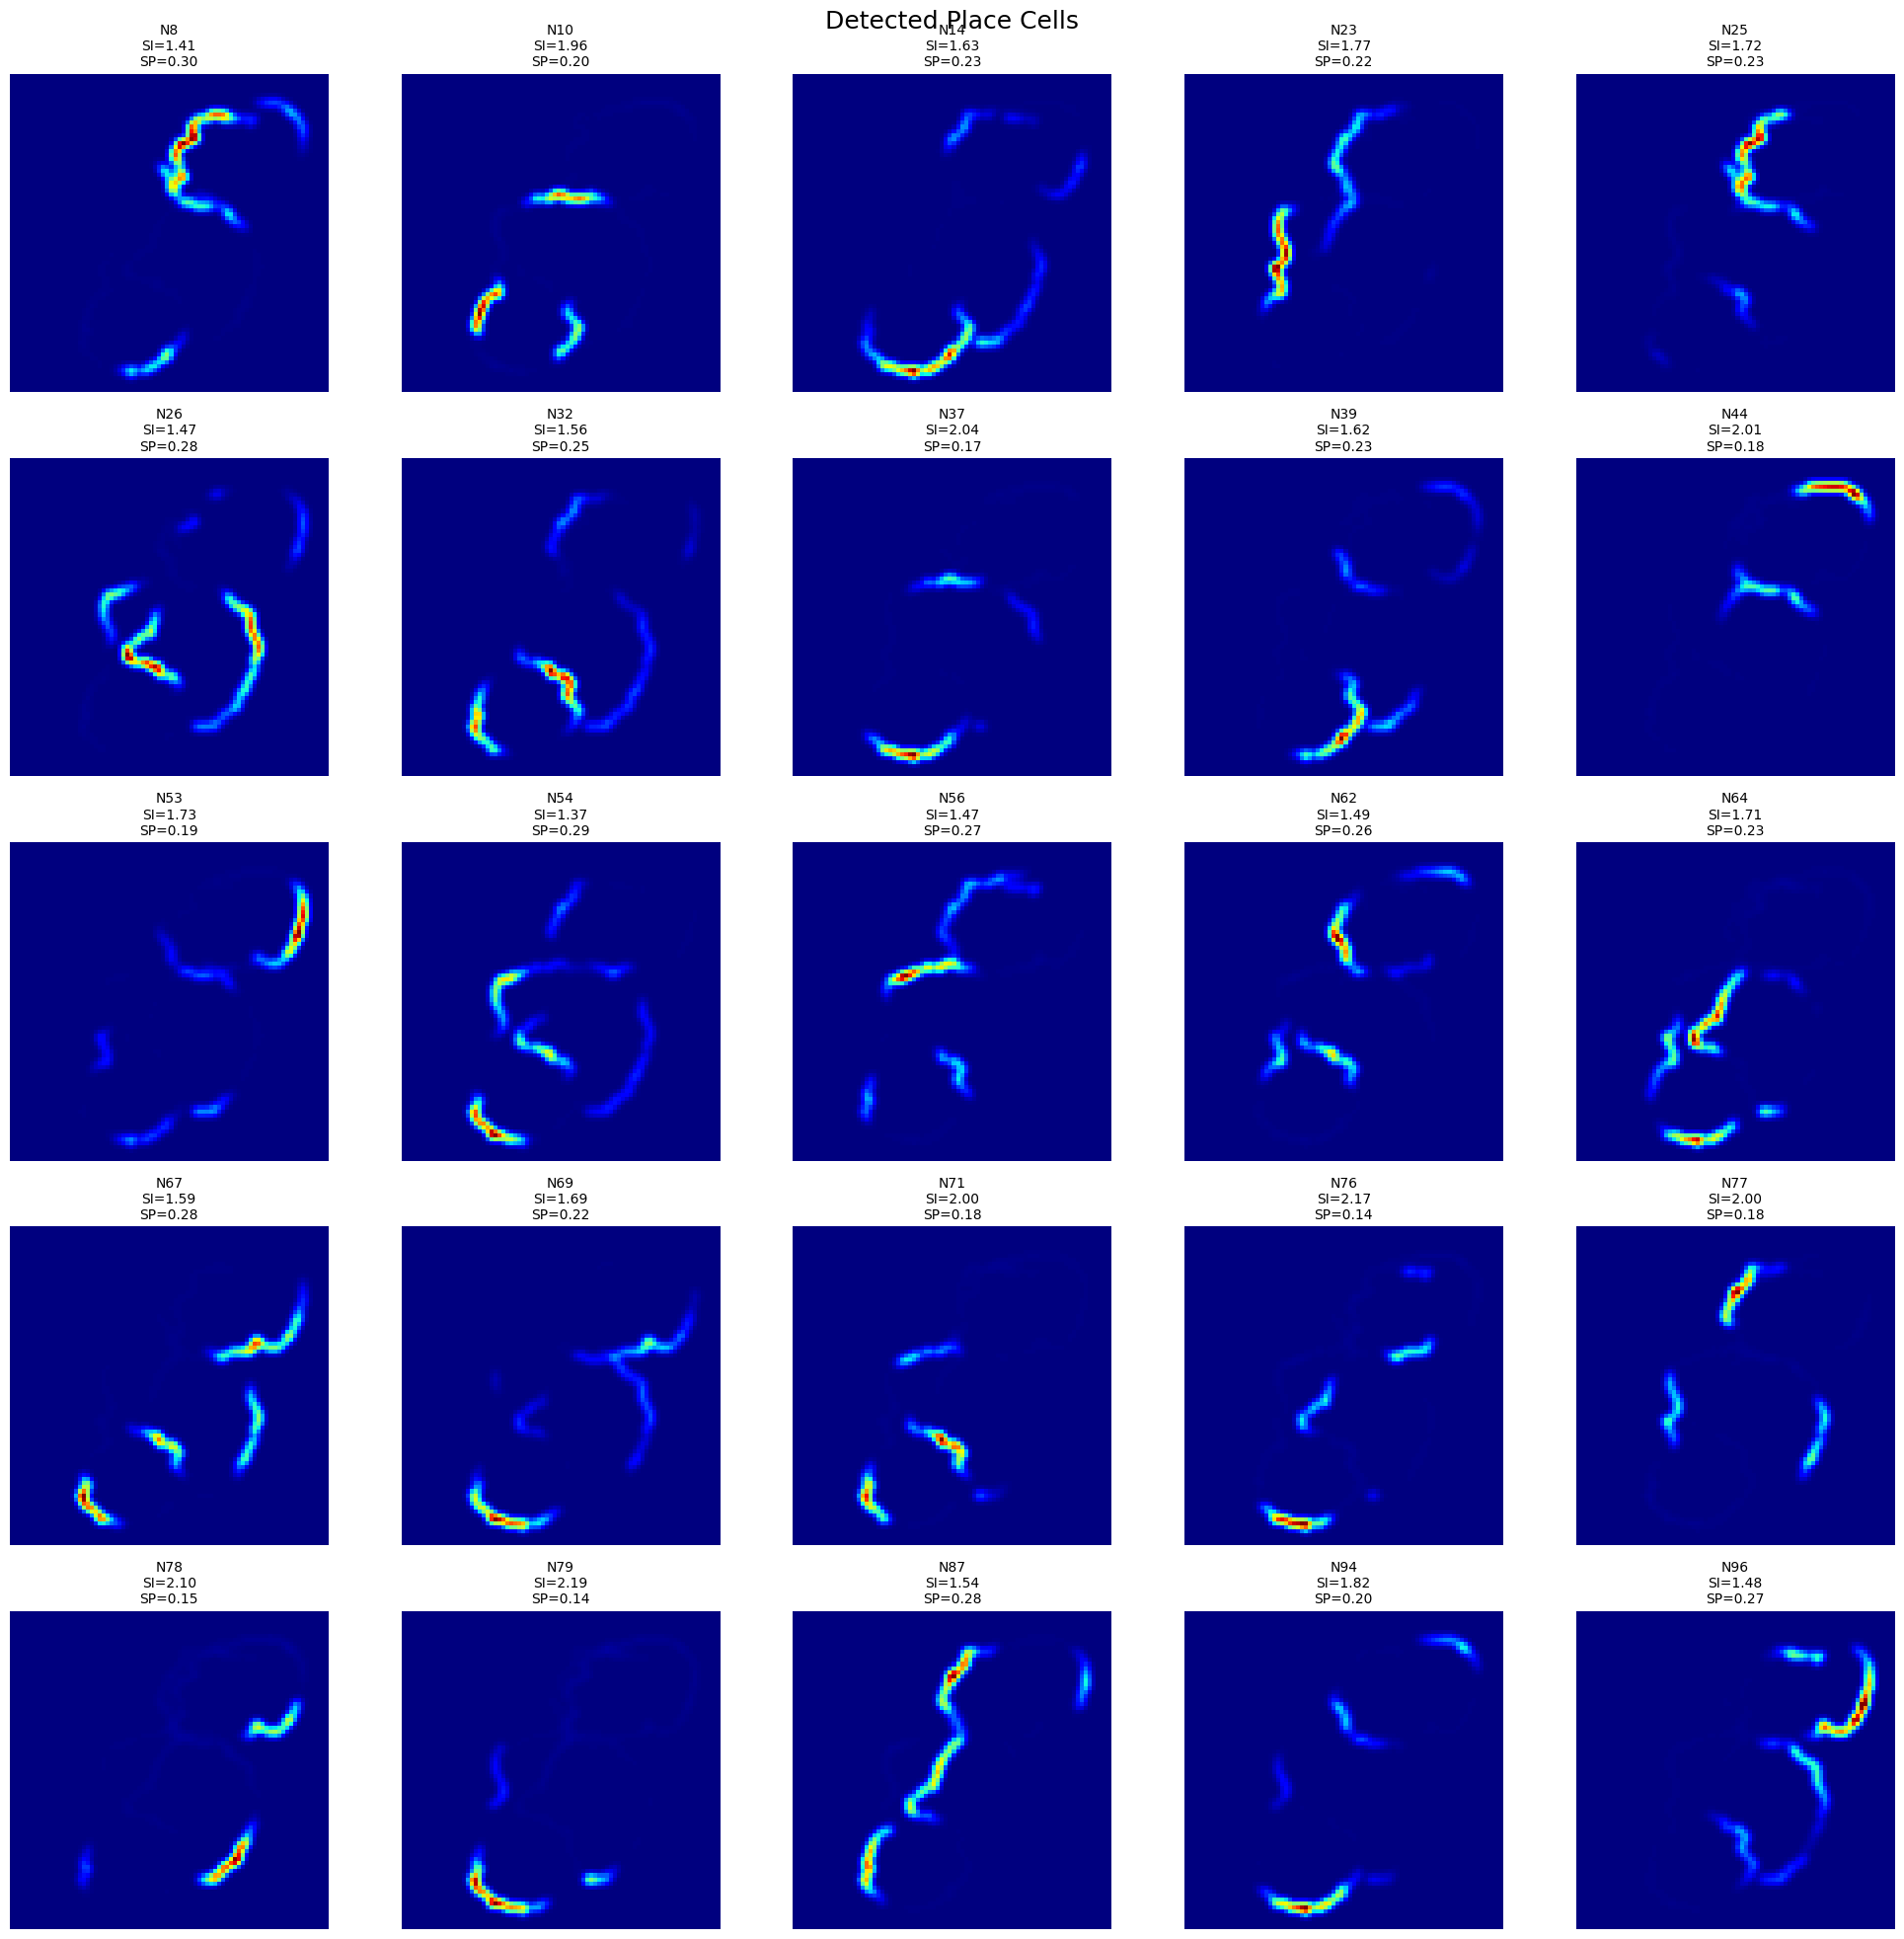

In [247]:
import math

n_cells = len(place_cells)

cols = 5
rows = math.ceil(n_cells / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(4 * cols, 4 * rows)
)

axes = axes.ravel()

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, place_cells.iterrows()):

    neuron = int(row["Neuron"])

    rate_map = all_results[neuron]["amp_count_smoothed"]

    im = ax.imshow(
        rate_map,
        origin="lower",
        cmap="jet",
    )

    ax.set_title(
        f"N{neuron}\n"
        f"SI={row['SI']:.2f}\n"
        f"SP={row['Sparsity']:.2f}",
        fontsize=10,
    )

    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Detected Place Cells",
    fontsize=18,
)

plt.tight_layout()

plt.show()

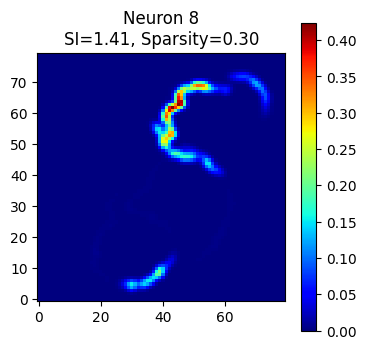

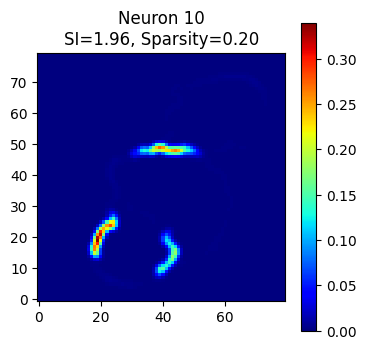

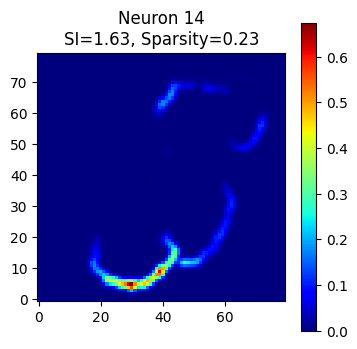

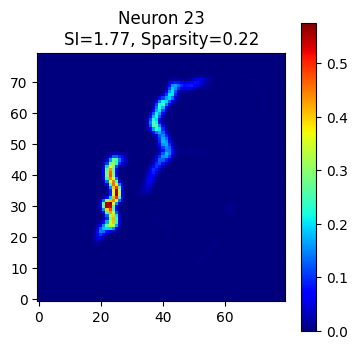

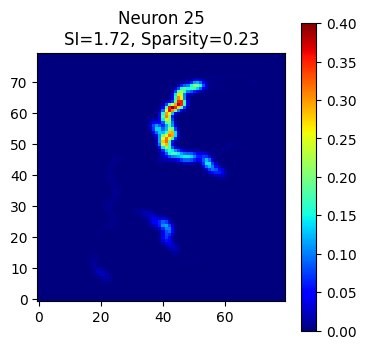

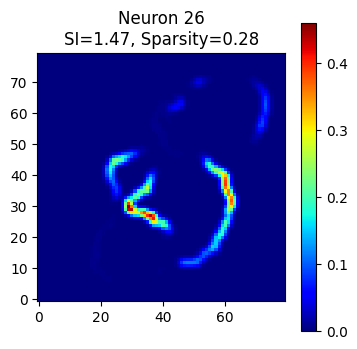

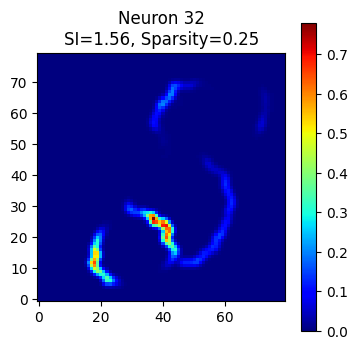

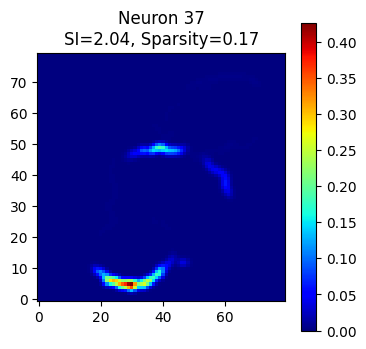

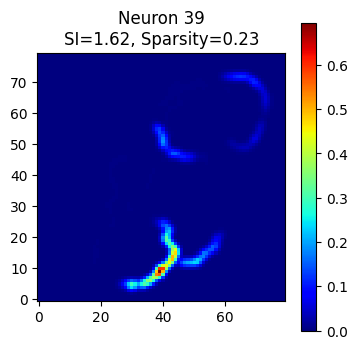

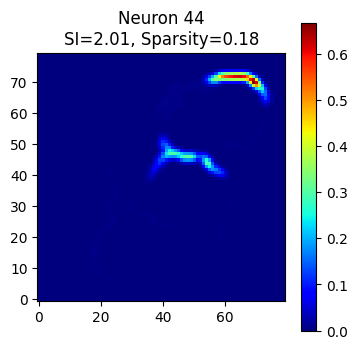

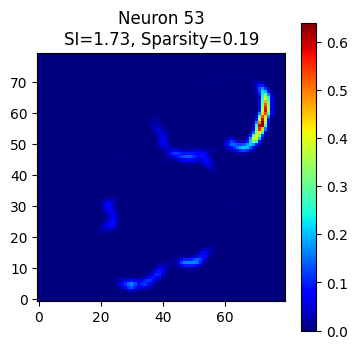

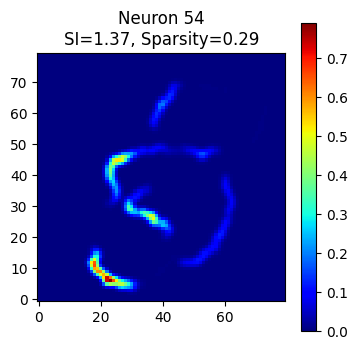

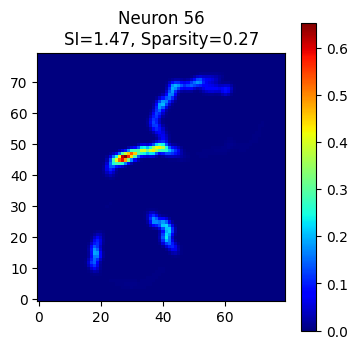

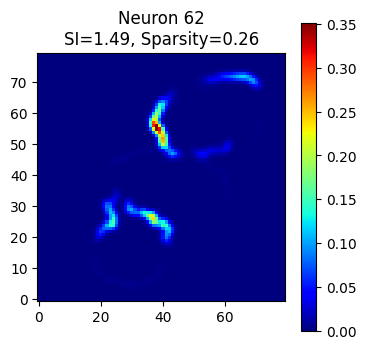

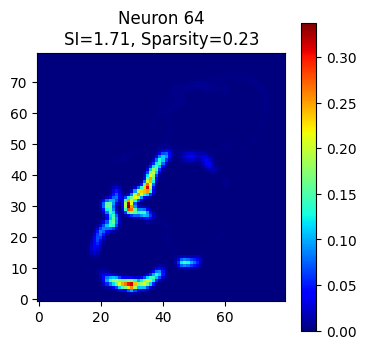

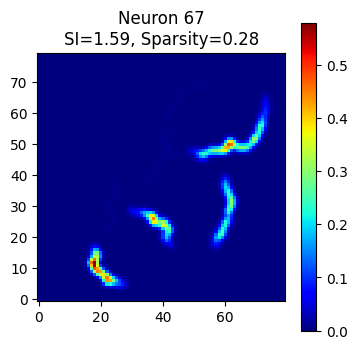

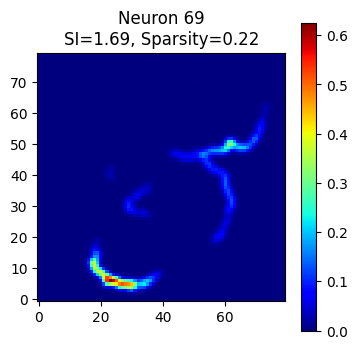

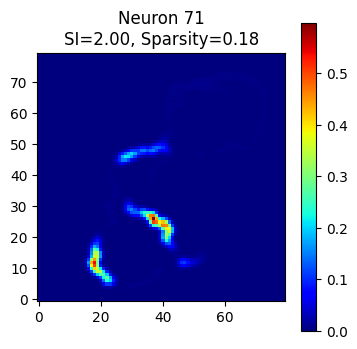

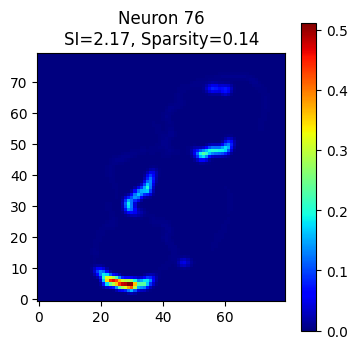

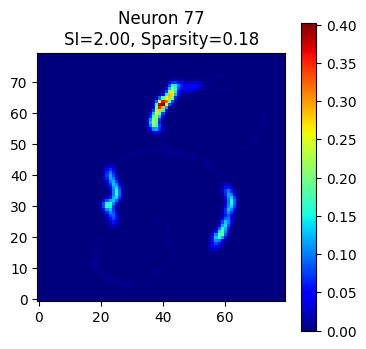

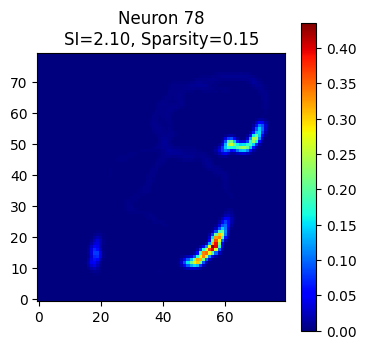

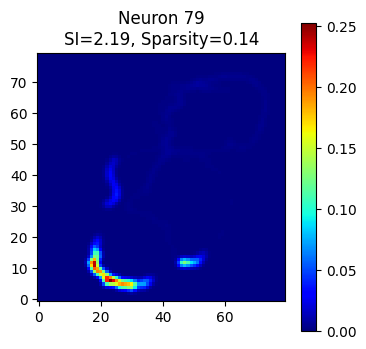

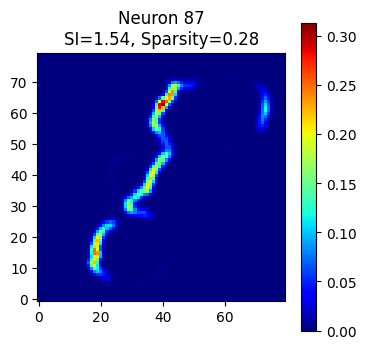

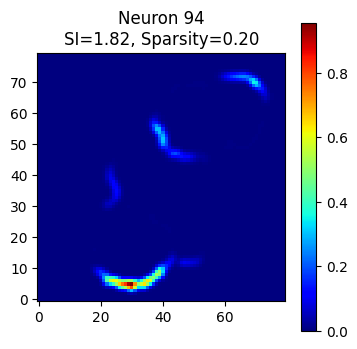

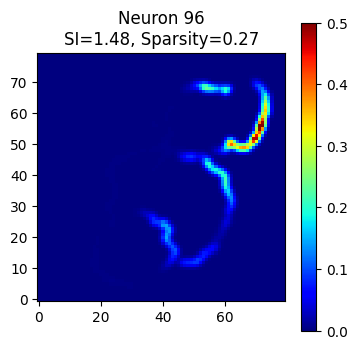

In [244]:
for _, row in place_cells.iterrows():

    neuron = int(row["Neuron"])

    rate_map = all_results[neuron]["amp_count_smoothed"]

    plt.figure(figsize=(4,4))

    plt.imshow(
        rate_map,
        origin="lower",
        cmap="jet",
    )

    plt.colorbar()

    plt.title(
        f"Neuron {neuron}\n"
        f"SI={row['SI']:.2f}, Sparsity={row['Sparsity']:.2f}"
    )

    plt.show()

In [241]:
print(results_df.dtypes)

Neuron        int64
SI          float64
Sparsity    float64
dtype: object
